# **Perbandingan Tokenizer mix**
Pada bagian ini akan dilakukan perbandingan dari tokenizer dari berbagai **vocabulay size** pada **mix-dataset**. Tujuan dari percobaan ini adalah untuk menilai seberapa baik tokenizer dapat melakukan tokenisasi dengan baik (memecah token secara utuh)

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns  

from transformers import BartTokenizer

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Load Dataset

In [2]:
# mix_datasets_8k_path = kagglehub.dataset_download('jawahirul/mix-datasets-8k')

df = pd.read_csv('/kaggle/input/fine-tuning/fine-tuning.csv')

documents = df['text'].tolist()

# Evaluasi Tokenizer

## Check Total Token

In [3]:
mix_10k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-mix/transformers/tokenizer-mix-10000/1')
mix_30k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-mix/transformers/tokenizer-mix-30000/1')
mix_50k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-mix/transformers/tokenizer-mix-50265/1')

# Fungsi untuk menghitung total kata dan token
def total_token(documents):
    word_counts = []
    mix_10k_counts = []
    mix_30k_counts = []
    mix_50k_counts = []

    for doc in documents:
            
        # Hitung jumlah kata dengan NLTK
        words = word_tokenize(doc)
        word_counts.append(len(words))

        # Hitung jumlah token dengan custom tokenizer
        mix_token_10k = mix_10k.encode(doc, add_special_tokens=False)
        mix_10k_counts.append(len(mix_token_10k))

        mix_token_30k = mix_30k.encode(doc, add_special_tokens=False)
        mix_30k_counts.append(len(mix_token_30k))

        mix_token_50k = mix_50k.encode(doc, add_special_tokens=False)
        mix_50k_counts.append(len(mix_token_50k))

    # Hitung total kata
    total_word_count = sum(word_counts)
    total_mix_10k = sum(mix_10k_counts)
    total_mix_30k = sum(mix_30k_counts)
    total_mix_50k = sum(mix_50k_counts)

    return total_word_count, total_mix_10k, total_mix_30k, total_mix_50k

In [4]:
# Format output ke ribuan
def format_thousands(number):
    return "{:,}".format(int(number)).replace(",", ".")
    
# Hitung total kata dan token
total_word_count, total_mix_10k, total_mix_30k, total_mix_50k = total_token(documents)

# Print hasil
print(f"Total kata (NLTK): {format_thousands(total_word_count)}")
print(f"Total token (mix-10k): {format_thousands(total_mix_10k)}")
print(f"Total token (mix-30k): {format_thousands(total_mix_30k)}")
print(f"Total token (mix-50k): {format_thousands(total_mix_50k)}")

Total kata (NLTK): 3.798.826
Total token (mix-10k): 5.159.961
Total token (mix-30k): 4.352.560
Total token (mix-50k): 4.189.544


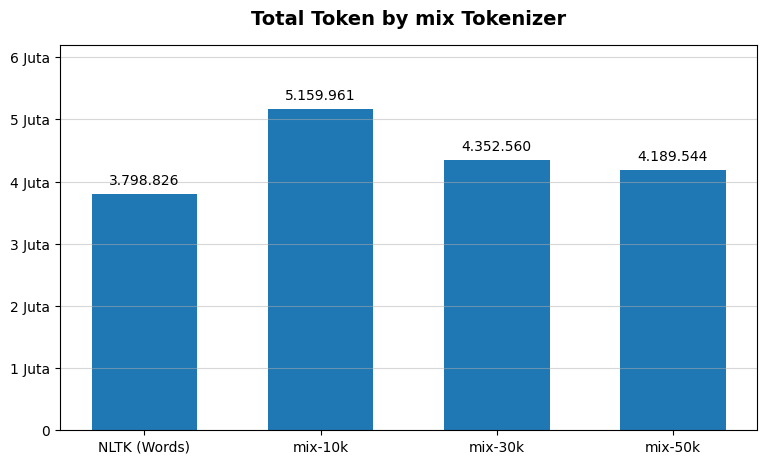

In [5]:
# Fungsi untuk visualisasi
def plot_total_token(total_word_count, total_mix_10k, total_mix_30k, total_mix_50k):
    labels = ['NLTK (Words)', 'mix-10k', 'mix-30k', 'mix-50k']
    values = [total_word_count, total_mix_10k, total_mix_30k, total_mix_50k]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(labels, values, width=0.6)
    
    # Menambahkan judul dan label
    plt.title('Total Token by mix Tokenizer', fontweight='semibold', fontsize=14, pad=15)
    # plt.ylabel('Total Token', fontsize=13, labelpad=15)
    # plt.xlabel('Tokenization Method', fontsize=13, labelpad=20)

    # Set grid dan panjang bar
    plt.grid(True, axis='y', alpha=0.5)
    plt.ylim(0, max(values) * 1.2) # mengatur panjang bar

    # Tambahkan nilai di atas setiap bar
    for i, v in enumerate(values):
        plt.text(i, v + max(values)*0.03, format_thousands(v), ha='center', fontsize=10)

    def juta_formatter(x, pos):
        """Mengubah angka tick menjadi format jutaan (misal: 2 Jt, 5.5 Jt)"""
        if x == 0:
            return '0'
        else:
            val_jt = x / 1e6
            # Jika nilainya adalah bilangan bulat setelah dibagi sejuta (misal 2.0, 3.0)
            # tampilkan tanpa desimal. Jika tidak (misal 2.5), tampilkan satu desimal.
            if val_jt == int(val_jt):
                return f'{val_jt:.0f} Juta'
            else:
                return f'{val_jt:.1f} Juta'

    # Dapatkan axes saat ini dan terapkan formatter ke sumbu Y
    ax = plt.gca()
    ax.yaxis.set_major_formatter(FuncFormatter(juta_formatter))

    plt.show()

#Visualisasi hasil
plot_total_token(total_word_count, total_mix_10k, total_mix_30k, total_mix_50k)


## Fertility Metric

In [6]:
# Fungsi   menghitung metrik fertility dari total token
def fertility_metric(total_word_count, total_tokens_10k, total_tokens_30k, total_tokens_50k):
    # Hitung fertility (total token / total kata asli)
    fertility_10k = total_tokens_10k / total_word_count
    fertility_30k = total_tokens_30k / total_word_count 
    fertility_50k = total_tokens_50k / total_word_count 

    return fertility_10k, fertility_30k, fertility_50k

In [7]:
# Hitung fertility dari total
fertility_10k, fertility_30k, fertility_50k = fertility_metric(
    total_word_count, total_mix_10k, total_mix_30k, total_mix_50k
)
    
# Print hasil fertility
print(f"Fertility (mix-10k): {fertility_10k:.2f}")
print(f"Fertility (mix-30k): {fertility_30k:.2f}")
print(f"Fertility (mix-50k): {fertility_50k:.2f}")

Fertility (mix-10k): 1.36
Fertility (mix-30k): 1.15
Fertility (mix-50k): 1.10


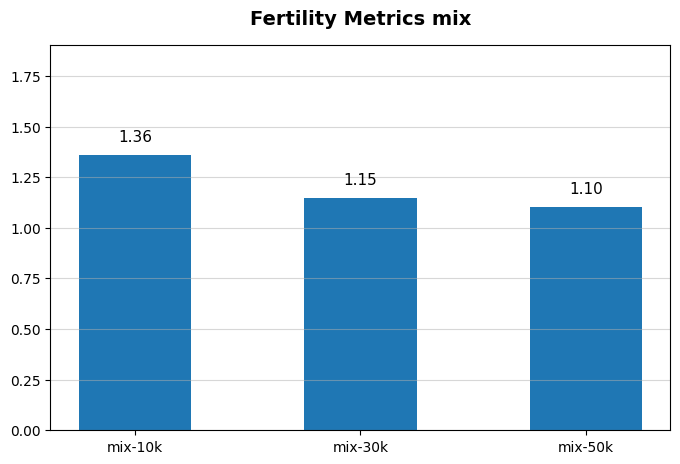

In [8]:
# Fungsi visualisasi fertility
def plot_fertility(fertility_10k, fertility_30k, fertility_50k):
    labels = ['mix-10k', 'mix-30k', 'mix-50k']
    values = [fertility_10k, fertility_30k, fertility_50k]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, width=0.5)

    # Set Judul dan label
    plt.title('Fertility Metrics mix', fontweight='semibold', fontsize=14, pad=15)
    # plt.ylabel('Tokens per Word', fontsize=13, labelpad=20)
    # plt.xlabel('Tokenizer', fontsize=13, labelpad=20)

    # Set grid dan panjang bar
    plt.grid(True, axis='y', alpha=0.5)
    plt.ylim(0, max(values) * 1.4) # Mengatur panjang bar

    # Tambahkan nilai di atas setiap bar
    for i, v in enumerate(values):
        plt.text(i, v + max(values)*0.05, f"{v:.2f}", ha='center', fontsize=11)

    plt.show()

# Visualisasi fertility
plot_fertility(fertility_10k, fertility_30k, fertility_50k)

# Contoh hasil tokenisasi tokenizer indomixedtufs4

In [9]:
# Input teks
text = 'Hindari gratifikasi untuk pemilu bersih.'

# Buat dictionary untuk menyimpan tokenizer Anda agar mudah diakses
tokenizers = {
    "mix-10k": mix_10k,
    "mix-30k": mix_30k,
    "mix-50k": mix_50k
}

def proses_encode_decode(tokenizer_name, tokenizer, text_input):
    
    print(f"--- Proses untuk {tokenizer_name} ---")

    # 1. Encode string ke ID token
    encoded_output = tokenizer.encode(text_input, return_tensors="pt")
    print(f"Encode {tokenizer_name}:\n{encoded_output}\n")

    # 2. Decode ID token ke string (keseluruhan)
    decoded_full_text = tokenizer.decode(encoded_output[0], skip_special_tokens=False)
    print(f"Decode {tokenizer_name} (keseluruhan):\n{decoded_full_text}\n")

    # 3. Decode masing-masing ID token
    print(f"Decode {tokenizer_name} (per token):")
    token_ids = encoded_output[0]  # Mengambil ID token
    decoded_individual_tokens = []
    
    for token_id in token_ids:
        # Ubah token_id menjadi list agar bisa di-decode
        decoded_token = tokenizer.decode([token_id.item()], skip_special_tokens=False)
        decoded_individual_tokens.append(decoded_token)
        print(f"  ID: {token_id.item():<5} -> Token: '{decoded_token}'")

    print(f"\n Total token {tokenizer_name}: {len(decoded_individual_tokens)}")
    print(decoded_individual_tokens)
    print("-" * 40 + "\n") # Pemisah antar tokenizer

# Loop melalui setiap tokenizer dan proses teksnya
for name, tokenizer_object in tokenizers.items():
    proses_encode_decode(name, tokenizer_object, text)
    

--- Proses untuk mix-10k ---
Encode mix-10k:
tensor([[   0,   44, 3896, 2273, 1054,  816,  361,  921, 4225,   18,    2]])

Decode mix-10k (keseluruhan):
<s>Hindari gratifikasi untuk pemilu bersih.</s>

Decode mix-10k (per token):
  ID: 0     -> Token: '<s>'
  ID: 44    -> Token: 'H'
  ID: 3896  -> Token: 'indari'
  ID: 2273  -> Token: ' gr'
  ID: 1054  -> Token: 'atif'
  ID: 816   -> Token: 'ikasi'
  ID: 361   -> Token: ' untuk'
  ID: 921   -> Token: ' pemilu'
  ID: 4225  -> Token: ' bersih'
  ID: 18    -> Token: '.'
  ID: 2     -> Token: '</s>'

 Total token mix-10k: 11
['<s>', 'H', 'indari', ' gr', 'atif', 'ikasi', ' untuk', ' pemilu', ' bersih', '.', '</s>']
----------------------------------------

--- Proses untuk mix-30k ---
Encode mix-30k:
tensor([[    0, 28694, 23920,   361,   921,  4225,    18,     2]])

Decode mix-30k (keseluruhan):
<s>Hindari gratifikasi untuk pemilu bersih.</s>

Decode mix-30k (per token):
  ID: 0     -> Token: '<s>'
  ID: 28694 -> Token: 'Hindari'
  ID: 23